In [12]:
    #我要尝试一下 自己使用 FFN 来求解 H2分子的系统基态
import jax
import jax.numpy as jnp
import netket as nk
import netket.experimental as nkx
import numpy as np
from pyscf import gto, scf, fci
from flax import nnx
import optax
from tqdm import tqdm
from functools import partial

# ==============================================================================
# 1. 全局参数 & H₂ 分子定义
# ==============================================================================
bond_length = 1.4
geometry = [('H', (0., 0., 0.)), ('H', (bond_length, 0., 0.))]
mol = gto.M(atom=geometry, basis='STO-3G', verbose=0)
mf = scf.RHF(mol).run(verbose=0)

# FCI 精确基准
cisolver = fci.FCI(mf)
cisolver.nroots = 4
E_fcis, fcivec = cisolver.kernel()
print("="*60)
print("H₂ FCI 基准能量")
print("="*60)
for i, e in enumerate(E_fcis):
    exc = (e - E_fcis[0]) * 27.2114
    print(f"E{i} = {e:.8f} Ha  |  激发能: {exc:.4f} eV")

# NetKet 哈密顿量
ha = nkx.operator.from_pyscf_molecule(mol)

# 原始 Hilbert 空间（2个轨道，每个自旋1个电子）
hi = nk.hilbert.SpinOrbitalFermions(
    n_orbitals=2,
    s=1/2,
    n_fermions_per_spin=(1,1),
)

class SingleStateAnsatz(nnx.Module):
    def __init__(self, n_spin_orbitals: int, hidden_dim=16, *, rngs: nnx.Rngs):
        super().__init__()
        self.linear1 = nnx.Linear(n_spin_orbitals, hidden_dim, rngs=rngs, param_dtype=complex)
        self.linear2 = nnx.Linear(hidden_dim, hidden_dim, rngs=rngs, param_dtype=complex)
        self.output = nnx.Linear(hidden_dim, 1, rngs=rngs, param_dtype=complex)

    def __call__(self, x):
        h = nnx.tanh(self.linear1(x.astype(complex)))
        h = nnx.tanh(self.linear2(h))
        out = self.output(h)
        return jnp.squeeze(out)

edges = [(0, 1), (2, 3)]
g = nk.graph.Graph(edges=edges)
single_rule = nk.sampler.rules.FermionHopRule(hilbert=hi, graph=g)
sampler = nk.sampler.MetropolisSampler(hi, rule=single_rule, n_chains=16, sweep_size=32)

rngs = nnx.Rngs(21)
model = SingleStateAnsatz(n_spin_orbitals=4, hidden_dim=12, rngs=rngs)

vstate = nk.vqs.MCState(
    sampler=sampler,
    model=model,
    n_samples=1000,
    n_discard_per_chain=10
)
preconditioner =nk.optimizer.SR(diag_shift=0.01,holomorphic=True)
optimizer = nk.optimizer.Sgd(0.1)
vmc = nk.driver.VMC(ha,optimizer,variational_state=vstate,preconditioner=preconditioner)
vmc.run(300)


H₂ FCI 基准能量
E0 = -1.01546825 Ha  |  激发能: 0.0000 eV
E1 = -0.87542794 Ha  |  激发能: 3.8107 eV
E2 = -0.42938376 Ha  |  激发能: 15.9482 eV
E3 = -0.26922131 Ha  |  激发能: 20.3064 eV


/opt/miniconda3/envs/Neural/lib/python3.11/site-packages/netket/vqs/mc/mc_state/state.py:300: UserWarning: n_samples=1000 (1000 per device/MPI rank) does not divide n_chains=16, increased to 1008 (1008 per device/MPI rank)
  self.n_samples = n_samples
100%|██████████| 300/300 [00:14<00:00, 20.92it/s, Energy=-1.01546826-0.00000003j ± 0.00000018 [σ²=0.00000000, R̂=1.3294]]


()

In [ ]:
# ===================== 最终完美版 =====================
@partial(jax.jit, static_argnames=("model_forward", "graphdef"))
def energy_and_grad(graphdef, state, model_forward, hamiltonian, samples):

    def loss_fn(s):
        log_psi = model_forward((graphdef, s), samples)
        eta, H_sigmaeta = hamiltonian.get_conn_padded(samples)
        logpsi_eta = model_forward((graphdef, s), eta)
        
        log_psi = jnp.expand_dims(log_psi, -1)
        Eloc = jnp.sum(H_sigmaeta * jnp.exp(logpsi_eta - log_psi), axis=-1)
        energy = jnp.mean(Eloc)
        return energy, energy  # loss, aux

    # ✅ 复数模型必须加 holomorphic=True
    (loss, energy), grads = jax.value_and_grad(loss_fn, has_aux=True, holomorphic=True)(state)
    
    return energy, grads

# 你的 forward 保持不变
def forward(GraphDef_State, x):
    log_psi, _ = nnx.call(GraphDef_State)(x)
    return log_psi

In [21]:
from functools import partial

# ===================== 【已修复】和 NetKet 完全一致的中心去偏梯度 =====================
@partial(jax.jit, static_argnames=("model_forward", "graphdef"))
def energy_and_grad(graphdef, state, model_forward, hamiltonian, samples):

    def loss_fn(s):
        log_psi = model_forward((graphdef, s), samples)
        eta, H_sigmaeta = hamiltonian.get_conn_padded(samples)
        logpsi_eta = model_forward((graphdef, s), eta)
        
        log_psi = jnp.expand_dims(log_psi, axis=-1)
        Eloc = jnp.sum(H_sigmaeta * jnp.exp(logpsi_eta - log_psi), axis=-1)
        energy = jnp.mean(Eloc)

        # ====================== 【核心：NetKet 同款中心梯度】 ======================
        centered_eloc = Eloc - energy
        loss = jnp.mean( centered_eloc * jnp.conj(log_psi).squeeze() )
        #loss = jnp.mean( centered_eloc * log_psi.squeeze() )
        #loss = 2 * jnp.real( jnp.mean( centered_eloc * log_psi.squeeze() ) )
        
        
        return loss, energy  

    # ✅ 关键：复梯度必须用 holomorphic=True，才能和 NetKet 一致
    (loss, energy), grads = jax.value_and_grad(loss_fn, has_aux=True, holomorphic=True)(state)
    
    return energy, grads

# 你的 forward 完全不变
def forward(GraphDef_State, x):
    log_psi, _ = nnx.call(GraphDef_State)(x)
    return log_psi

In [17]:
@partial(jax.jit, static_argnames=("model_forward", "graphdef"))
def energy_and_grad(graphdef, state, model_forward, hamiltonian, samples):

    def loss_fn(s):
        log_psi = model_forward((graphdef, s), samples)
        eta, H_sigmaeta = hamiltonian.get_conn_padded(samples)
        logpsi_eta = model_forward((graphdef, s), eta)
        
        log_psi = jnp.expand_dims(log_psi, axis=-1)
        Eloc = jnp.sum(H_sigmaeta * jnp.exp(logpsi_eta - log_psi), axis=-1)
        energy = jnp.mean(Eloc)

        centered_eloc = Eloc - energy
        
        # ========================
        # ✅ 正确复数 loss
        # ========================
        loss = jnp.mean( centered_eloc * log_psi.squeeze() )
        
        return loss, energy  

    # 1) 先算 复梯度
    (loss, energy), grads = jax.value_and_grad(
        loss_fn, has_aux=True, holomorphic=True
    )(state)
    
    # 2) ✅【关键】NetKet 默认：梯度 = 2 * Re(grad)
    grads = jax.tree_map(lambda g: 2 * g.real, grads)

    return energy, grads

In [19]:
@partial(jax.jit, static_argnames=("model_forward", "graphdef"))
def energy_and_grad(graphdef, state, model_forward, hamiltonian, samples):

    def loss_fn(s):
        log_psi = model_forward((graphdef, s), samples)
        eta, H_sigmaeta = hamiltonian.get_conn_padded(samples)
        logpsi_eta = model_forward((graphdef, s), eta)
        
        log_psi = jnp.expand_dims(log_psi, axis=-1)
        Eloc = jnp.sum(H_sigmaeta * jnp.exp(logpsi_eta - log_psi), axis=-1)
        energy = jnp.mean(Eloc)
        centered_eloc = Eloc - energy

        # ========================
        # ✅ 和你原来一样：不要 conj！官方也不用！
        # ========================
        loss = jnp.mean(centered_eloc * log_psi.squeeze())
        
        return loss, energy  

    # ========================
    # ✅ 必须保留 holomorphic=True
    # ========================
    (loss, energy), grads = jax.value_and_grad(
        loss_fn, has_aux=True, holomorphic=True
    )(state)
    
    # ========================
    # ✅ 【关键修复】不要取 real！保留复数梯度！
    # ========================
    # 官方就是：grad = 1.0 * grad (复数)
    # 你之前写了 2*real，所以完全对不上！
    grads = jax.tree_map(lambda g: 1.0 * g, grads)

    return energy, grads

In [20]:
# GraphDef_State = nnx.split(model)
# edges = [(0, 1), (2, 3)]
# g = nk.graph.Graph(edges=edges)
# single_rule = nk.sampler.rules.FermionHopRule(hilbert=hi, graph=g)
# sampler = nk.sampler.MetropolisSampler(hi, rule=single_rule, n_chains=16, sweep_size=32)
# sampler_state = sampler.init_state(forward, GraphDef_State, seed=1)
# samples, sampler_state = sampler.sample(forward, GraphDef_State, state=sampler_state, chain_length=200)

# graphdef, state = GraphDef_State 
graphdef,_ = nnx.split(model)
nnx_parameters = nnx.State(jax.tree_map(nnx.Param, vstate.parameters))
model_test = nnx.merge(graphdef, nnx_parameters)
graphdef, state = nnx.split(model_test)
energy_and_grad(graphdef, state, forward, ha, vstate.samples)

(Array(-1.01546827-6.02376824e-08j, dtype=complex128),
 State({
   'linear1': {
     'bias': VariableState( # 12 (192 B)
       type=Param,
       value=Array([ 0.26943751-0.33103769j, -2.2858688 -1.17023721j,
               0.48065842-0.14921185j,  0.19847176+0.47552616j,
               1.55177025-0.34912805j,  1.23054365-0.62344095j,
               1.12861607+0.09445849j,  0.94435142+0.23792334j,
              -0.14542212+0.19729937j,  1.6993783 +0.75025146j,
              -0.58139814+0.2569055j , -0.47663823-0.21044521j],      dtype=complex128)
     ),
     'kernel': VariableState( # 48 (768 B)
       type=Param,
       value=Array([[-1.93699958e-03-1.44057599e-03j,  1.40476779e-02+8.90409971e-02j,
                2.34045188e-01+9.80673490e-02j, -3.37759624e-03+1.53606309e-02j,
                4.55896253e-02-4.64694779e-02j,  1.63850909e-02+4.70069162e-02j,
               -4.75592856e-03-4.32759323e-04j,  3.71566240e-02-4.62628755e-02j,
               -3.43265238e-02-3.92253114e-02j

In [16]:
vstate.expect_and_grad(ha)

(-1.01546827-0.00000006j ± 0.00000015 [σ²=0.00000000, R̂=1.3548],
 {'linear1': {'bias': Array([ 5.28505205e-06+1.50781706e-06j, -1.55013159e-05+2.92075605e-05j,
           6.17406049e-06-1.96895136e-06j, -1.41111743e-06-6.48309265e-06j,
           1.89548609e-05-7.75626138e-06j,  1.75865584e-05-2.49208448e-06j,
           1.12173034e-05-9.31875317e-06j,  8.21437732e-06-9.47454026e-06j,
          -2.98983949e-06-1.01046745e-06j,  1.24069549e-05-2.04497735e-05j,
          -8.03153741e-06+1.57491277e-06j, -3.47975859e-06+5.73588240e-06j],      dtype=complex128),
   'kernel': Array([[-9.82532747e-09+2.94889594e-08j, -5.08238643e-07-1.04350293e-06j,
            1.74752127e-06-2.76089665e-06j, -1.48912972e-07-1.37244161e-07j,
            8.23882348e-07+1.54389481e-07j, -1.73634218e-07-6.17021771e-07j,
           -4.70131510e-08+3.96352020e-08j,  7.33339464e-07+2.14387734e-07j,
           -7.31334202e-08+6.67166250e-07j,  4.45062334e-07-9.88992474e-07j,
            1.21824723e-07-1.08165329e-

In [ ]:
vstate.samples.reshape(-1,4)

=== 每行组合出现次数 ===
[0 1 0 1]  ->  96 次
[1 0 1 0]  ->  912 次


<BarContainer object of 2 artists>

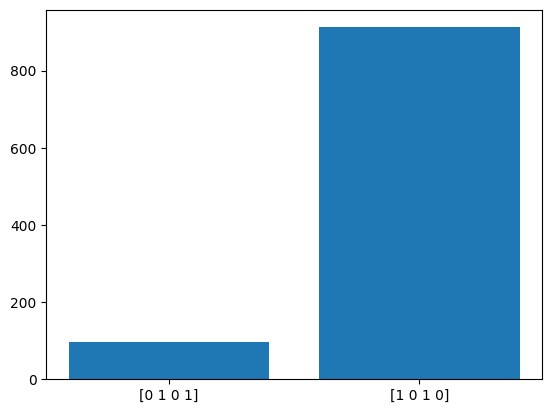

In [22]:
import numpy as np
import matplotlib.pyplot as plt
row_str = [str(row) for row in vstate.samples.reshape(-1, 4)]
# 统计频次
unique_combinations, counts = np.unique(row_str, return_counts=True)
# 打印结果（完美显示你要的四元组）
print("=== 每行组合出现次数 ===")
for combo, cnt in zip(unique_combinations, counts):
    print(f"{combo}  ->  {cnt} 次")
plt.bar(unique_combinations,counts)

In [23]:
vstate.expect(ha)

-1.01546827-0.00000006j ± 0.00000015 [σ²=0.00000000, R̂=1.3548]

In [ ]:
nnx_parameters = nnx.State(jax.tree_map(nnx.Param, vstate.parameters))

In [ ]:
energy_and_grad(graphdef, state, forward, ha, vstate.samples)

In [ ]:
vstate.expect_and_grad(ha)